# 03 - Full-Waveform Inversion (FWI)

This notebook is the third in a series of tutorial highlighting various aspects of seismic inversion based on Devito operators. In this second example we aim to highlight the core ideas behind seismic inversion, where we create an image of the subsurface from field recorded data. This tutorial follows on the modelling tutorial and will reuse the modelling and velocity model.

## Inversion requirement

Seismic inversion relies on two known parameters:

- **Field data** - or also called **recorded data**. This is a shot record corresponding to the true velocity model. In practice this data is acquired as described in the first tutorial. In order to simplify this tutorial we will fake field data by modelling it with the true velocity model.

- **Initial velocity model**. This is a velocity model that has been obtained by processing the field data. This model is a rough and very smooth estimate of the velocity as an initial estimate for the inversion. This is a necessary requirement for any optimization (method).

## Inversion computational setup

In this tutorial, we will introduce the gradient operator. This operator corresponds to the imaging condition introduced in the previous tutorial with some minor modifications that are defined by the objective function (also referred to in the tutorial series as the *functional*, *f*) and its gradient, *g*. We will define these two terms in the tutorial too.

## Notes on the operators

As we have already described the creation of a forward modelling operator, we will only call a wrapper function here. This wrapper already contains all the necessary operators for seismic modeling, imaging and inversion. Operators introduced for the first time in this tutorial will be properly described.

In [48]:
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")

In [49]:
import numpy as np
%matplotlib inline

from devito import configuration
configuration['log-level'] = 'WARNING'

## Computational considerations

As we will see, FWI is computationally extremely demanding, even more than RTM. To keep this tutorial as lightwight as possible we therefore again use a very small demonstration model. We also define here a few parameters for the final example runs that can be changed to modify the overall runtime of the tutorial.

In [95]:
nshots = 9  # Number of shots to create gradient from
nreceivers = 48  # Number of receiver locations per shot 
fwi_iterations = 5  # Number of outer FWI iterations

# True and smooth velocity models

We will use a very simple model domain, consisting of a circle within a 2D domain. We will again use the "true" model to generate our synthetic shot data and use a "smooth" model as our initial guess. In this case the smooth model is very smooth indeed - it is simply a constant background velocity without any features.

In [96]:
#NBVAL_IGNORE_OUTPUT
from examples.seismic import demo_model, plot_velocity, plot_perturbation

# Define true and initial model
shape = (51, 101)  # Number of grid point (nx, nz)
spacing = (0.5, 0.5)  # Grid spacing in m. The domain size is now 1km by 1km
origin = (0., 0.)  # Need origin to define relative source and receiver locations

model = demo_model('layers-isotropic', nlayers=5,
                    origin=origin, shape=shape, spacing=spacing, nbl=300)
model0 = demo_model('layers-isotropic', nlayers=5,
                    origin=origin, shape=shape, spacing=spacing, nbl=300)
from devito import gaussian_smooth

gaussian_smooth(model0.vp, sigma=3)
# model0 = demo_model('circle-isotropic', vp_circle=2.5, vp_background=2.5,
#                      origin=origin, shape=shape, spacing=spacing, nbl=40,
#                      grid = model.grid)
# plot_perturbation(model0, model)

vp(x, y)

In [97]:
# assert model.grid == model0.grid
# assert model.vp.grid == model0.vp.grid

## Acquisition geometry

In this tutorial, we will use the easiest case for inversion, namely a transmission experiment. The sources are located on one side of the model and the receivers on the other side. This allows to record most of the information necessary for inversion, as reflections usually lead to poor inversion results.

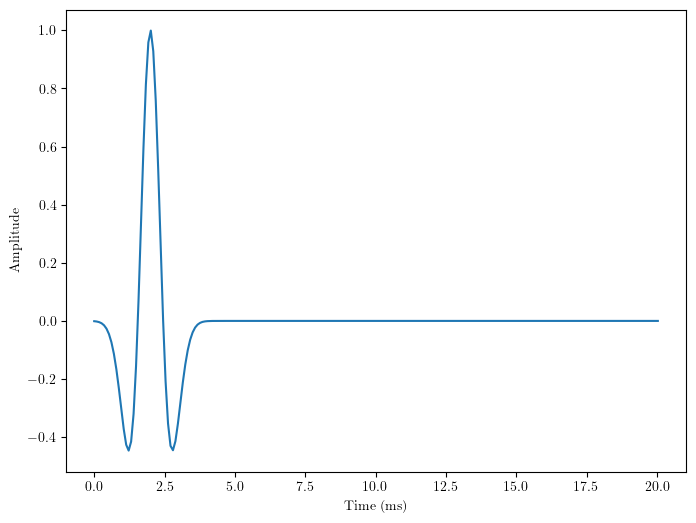

In [125]:
#NBVAL_IGNORE_OUTPUT
# Define acquisition geometry: source
from examples.seismic import AcquisitionGeometry

t0 = 0.
tn = 20. 
f0 = 0.5
# First, position source centrally in all dimensions, then set depth
src_coordinates = np.empty((1, 2))
src_coordinates[0, :] = np.array(model.domain_size) * .5
src_coordinates[0, 0] = 2.  # Depth is 20m


# Define acquisition geometry: receivers

# Initialize receivers for synthetic and imaging data
rec_coordinates = np.empty((nreceivers, 2))
rec_coordinates[:, 1] = 1.5 + np.linspace(0, 47, num=nreceivers)
rec_coordinates[:, 0] = 23.

# Geometry

geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')
# We can plot the time signature to see the wavelet
geometry.src.show()

In [126]:
from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

In [127]:
import numpy as np
from scipy.fft import fft, ifft, fftshift, ifftshift, rfft, irfft
from scipy.signal import hilbert

def minimal_phase_wavelet(wav_data):
    """
    Compute the minimal phase analogue of a wavelet.
    
    Parameters:
    - wav_data: Wavelet time-series data (1D array)
    - dt: Time step (sampling interval in seconds)
    
    Returns:
    - minimal_phase_wave: Minimal phase version of the wavelet
    """
    spec = fft(wav_data)
    arg_s = np.angle(spec)
    z_sup = hilbert(np.log(np.abs(spec)))
    arg_s_m = np.imag(z_sup)
    spec_s_m = abs(spec) * np.exp(-1j * arg_s_m)
    s_m = ifft(spec_s_m).real
    
    return s_m

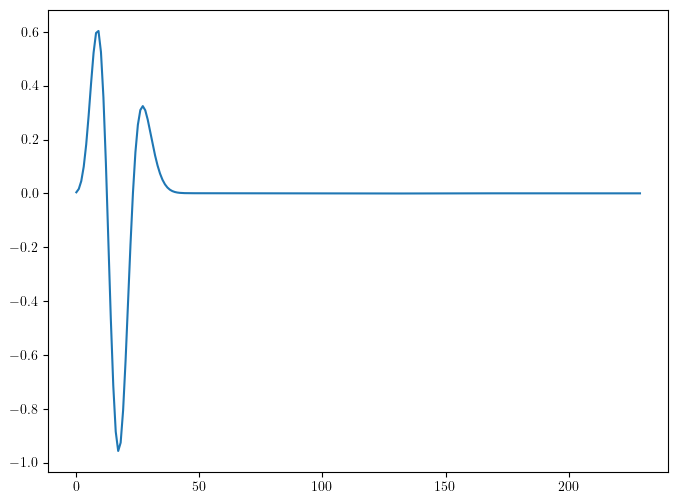

In [142]:
geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type='Ricker')

wav_min = minimal_phase_wavelet(np.array(geometry.src.data).ravel() + np.random.normal(scale=0.001))
# wav_min, _ = left_taper_tukey(wav_min[::-1], alpha=0.99)
# wav_min[50:] *= (np.arange(wav_min[50:].size, dtype=float)+1)**(-2)
plt.plot(wav_min)
plt.show()
geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type=None, wav_data=-wav_min)

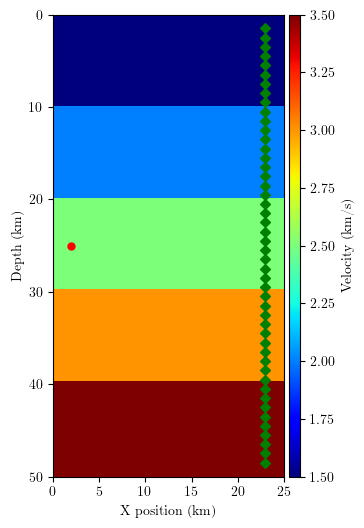

In [143]:
#NBVAL_IGNORE_OUTPUT
# Plot acquisition geometry
plot_velocity(model, source=geometry.src_positions,
              receiver=geometry.rec_positions[:, :])

## True and smooth data

We can generate shot records for the true and smoothed initial velocity models, since the difference between them will again form the basis of our imaging procedure.

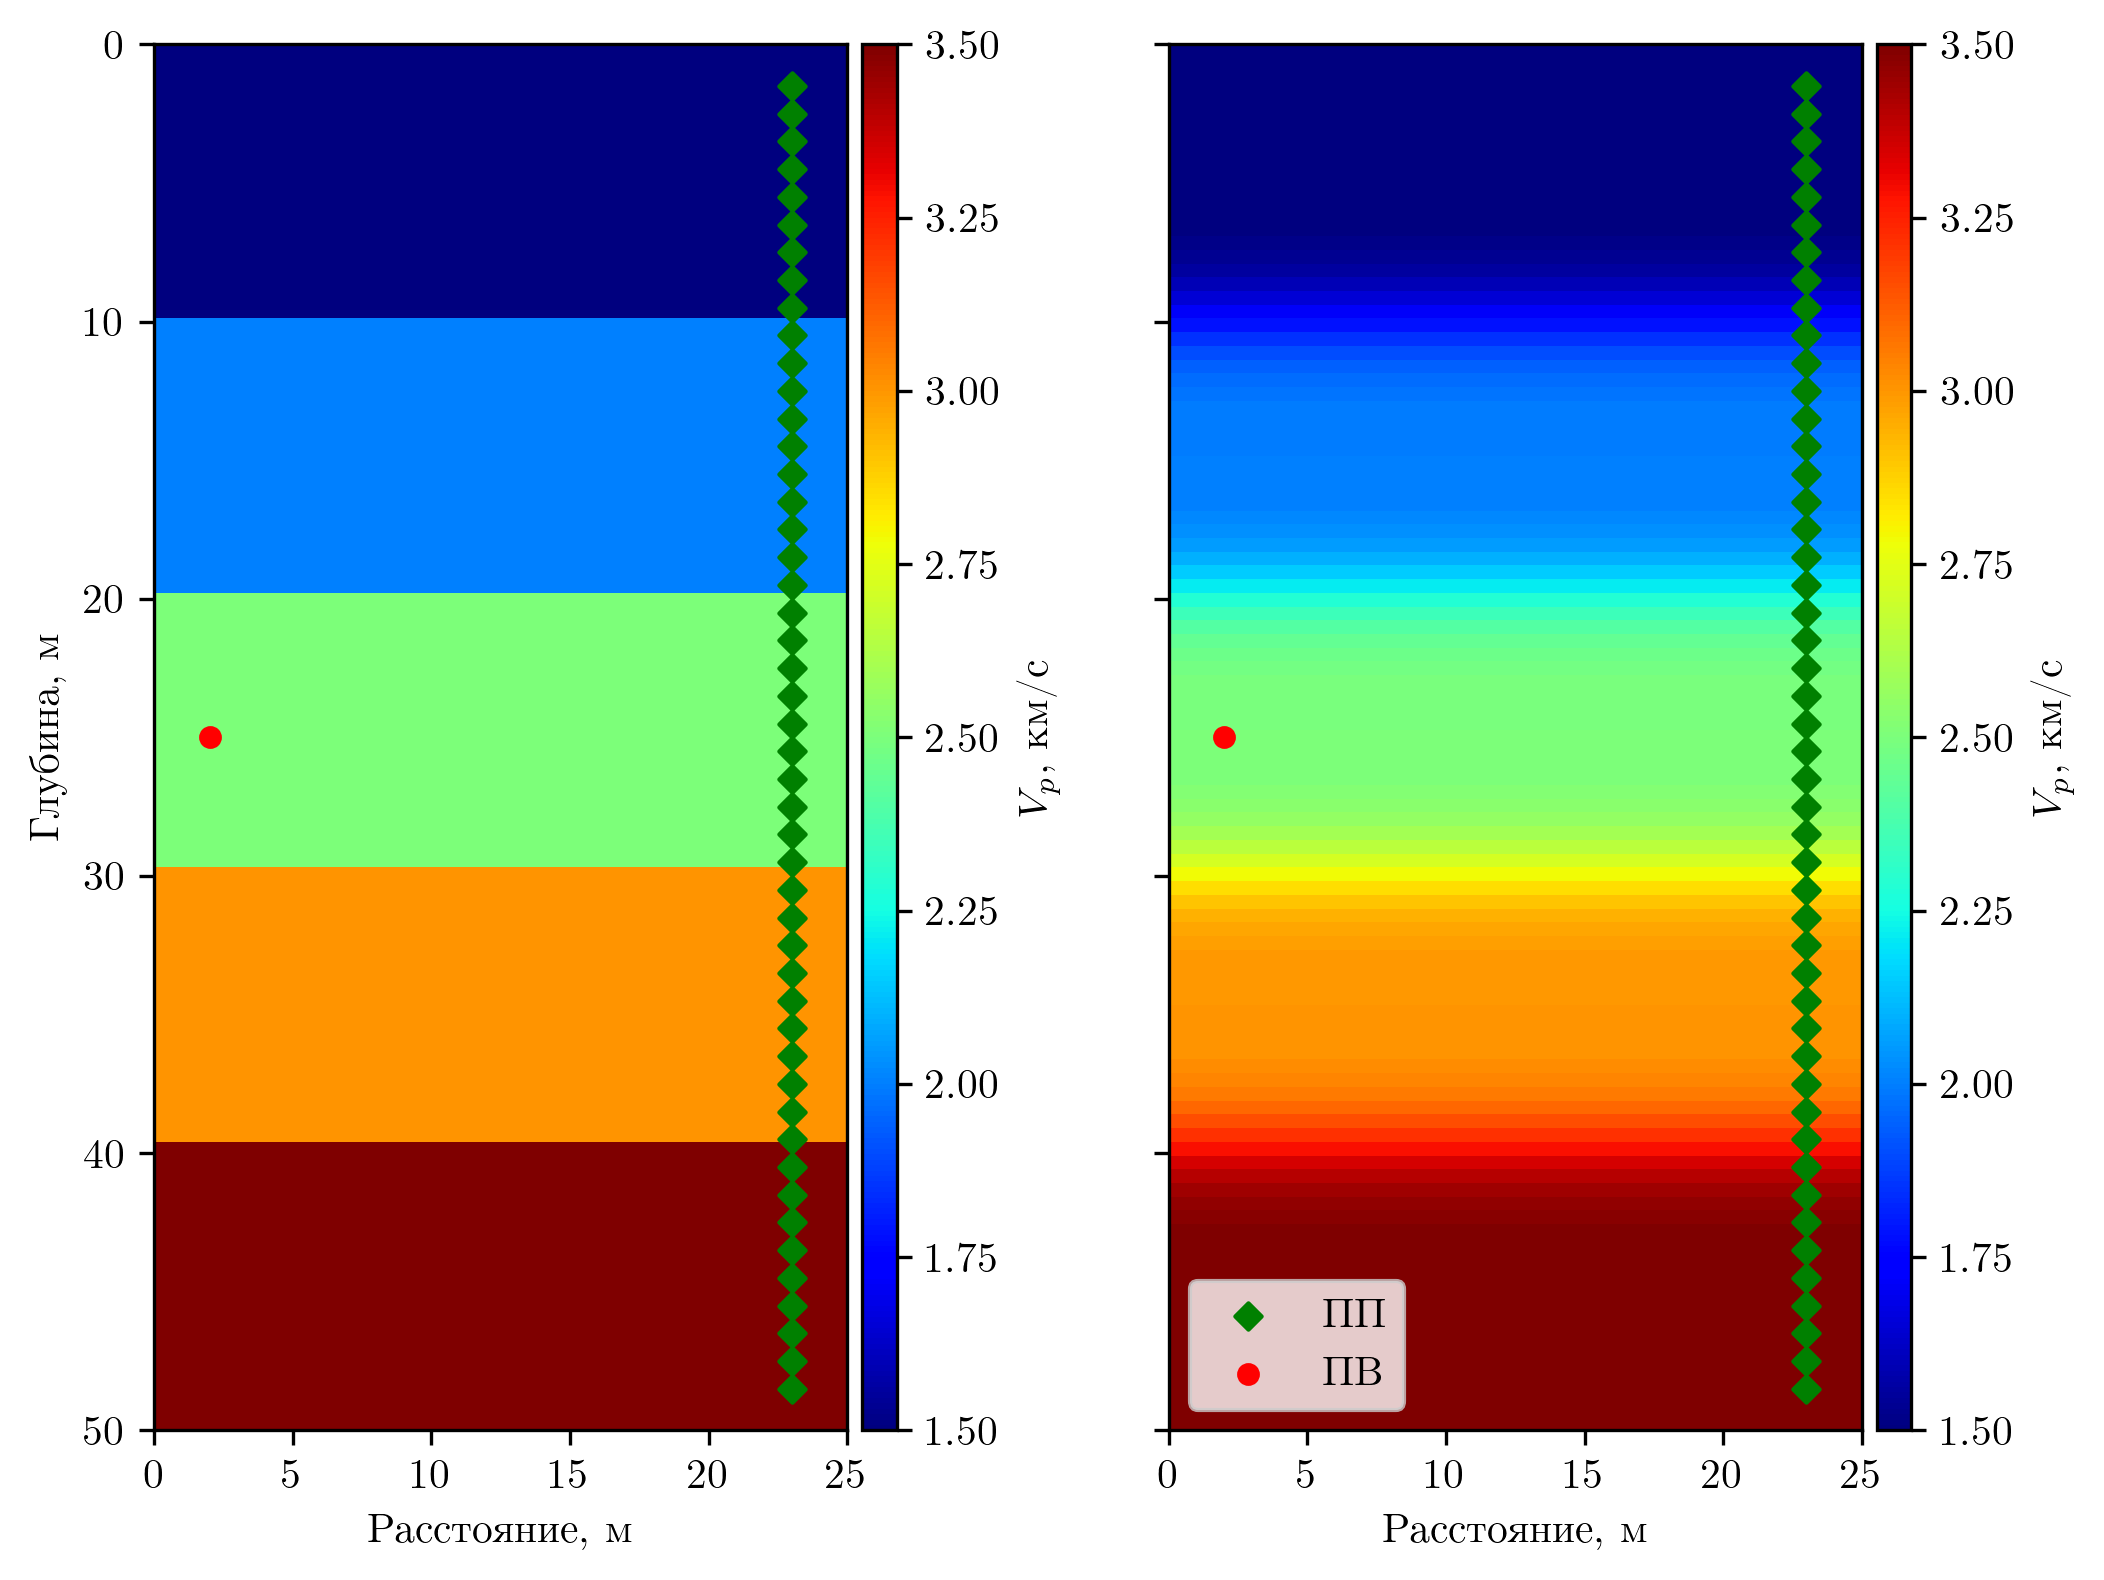

In [144]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

domain_size = np.array(model.domain_size)
extent = [
    model.origin[0],
    model.origin[0] + domain_size[0],
    model.origin[1] + domain_size[1],
    model.origin[1],
]
slices = tuple(slice(model.nbl, -model.nbl) for _ in range(2))
fig, axs = plt.subplots(1, 2, dpi=300, sharey=True)
for ax, mo in zip(axs, [model, model0]):
    field = mo.vp.data[slices]

    plot = ax.imshow(
        np.transpose(field),
        animated=True,
        cmap="jet",
        vmin=np.min(field),
        vmax=np.max(field),
        extent=extent,
    )
    ax.set_xlabel("Расстояние, м")
    ax.scatter(rec_coordinates[:, 0], rec_coordinates[:, 1], s=20, c="green", marker="D", label="ПП")
    ax.scatter(src_coordinates[:, 0], src_coordinates[:, 1], s=20, c="red", marker="o", label="ПВ")

    # Ensure axis limits
    ax.set_xlim(model.origin[0], model.origin[0] + domain_size[0])
    ax.set_ylim(model.origin[1] + domain_size[1], model.origin[1])

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(plot, cax=cax)
    cbar.set_label(r"$V_p$, км/с")
axs[0].set_ylabel("Глубина, м")
axs[1].legend(loc='lower left')
plt.savefig("../../../Wavelet part pics/Pic0.png")
plt.show()

In [145]:
# Compute synthetic data with forward operator 
from examples.seismic.acoustic import AcousticWaveSolver

solver = AcousticWaveSolver(model, geometry, space_order=4)
true_d, _, _ = solver.forward(vp=model.vp)

In [146]:
# # Compute initial data with forward operator 
# smooth_d, _, _ = solver.forward(vp=model0.vp)

(48, 230)


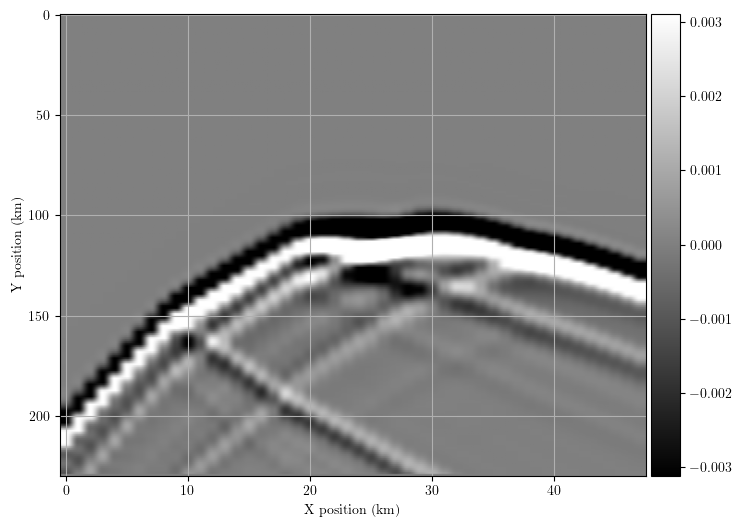

In [147]:
#NBVAL_IGNORE_OUTPUT
from examples.seismic import plot_shotrecord
from matplotlib import pyplot as plt
# Plot shot record for true and smooth velocity model and the difference
ax = plot_shotrecord(true_d.data.T, model, t0, tn)
plt.show()
# plot_shotrecord(smooth_d.data, model, t0, tn)
# plot_shotrecord(smooth_d.data - true_d.data, model, t0, tn)

In [148]:
arr = np.array(true_d.data)
arr_norm = arr/np.linalg.norm(arr, axis=0)
threshold = 0.03
fbs = np.argmax(np.abs(arr_norm) > threshold, axis=0)

In [149]:
import numpy as np

# Shift each column and fill with zeros
shifted_arr = np.zeros_like(arr)
for col in range(arr.shape[1]):
    shift_amount = -fbs[col]  # Negative to shift upward
    if shift_amount < 0:
        # Shift upward, fill bottom with zeros
        shifted_arr[:shift_amount, col] = arr[-shift_amount:, col]
    elif shift_amount > 0:
        # Shift downward, fill top with zeros
        shifted_arr[shift_amount:, col] = arr[:-shift_amount, col]
    else:
        # No shift
        shifted_arr[:, col] = arr[:, col]

(48, 230)


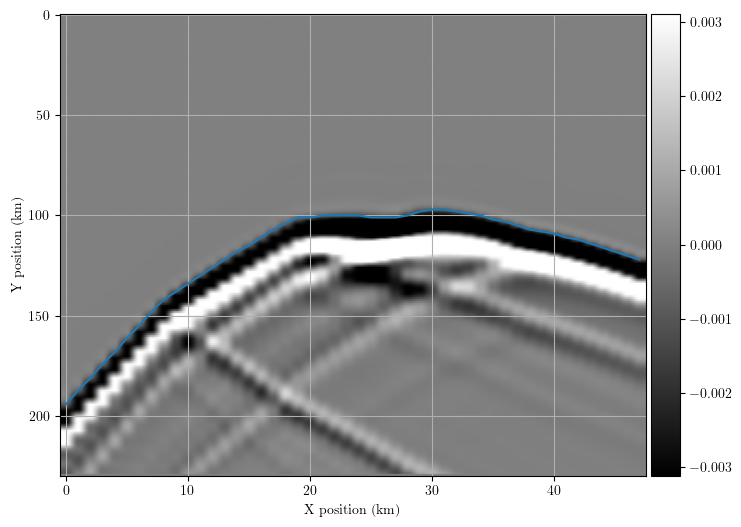

In [150]:
ax = plot_shotrecord(true_d.data.T, model, t0, tn)
ax.plot(np.arange(true_d.data.shape[1]), fbs)
plt.show()

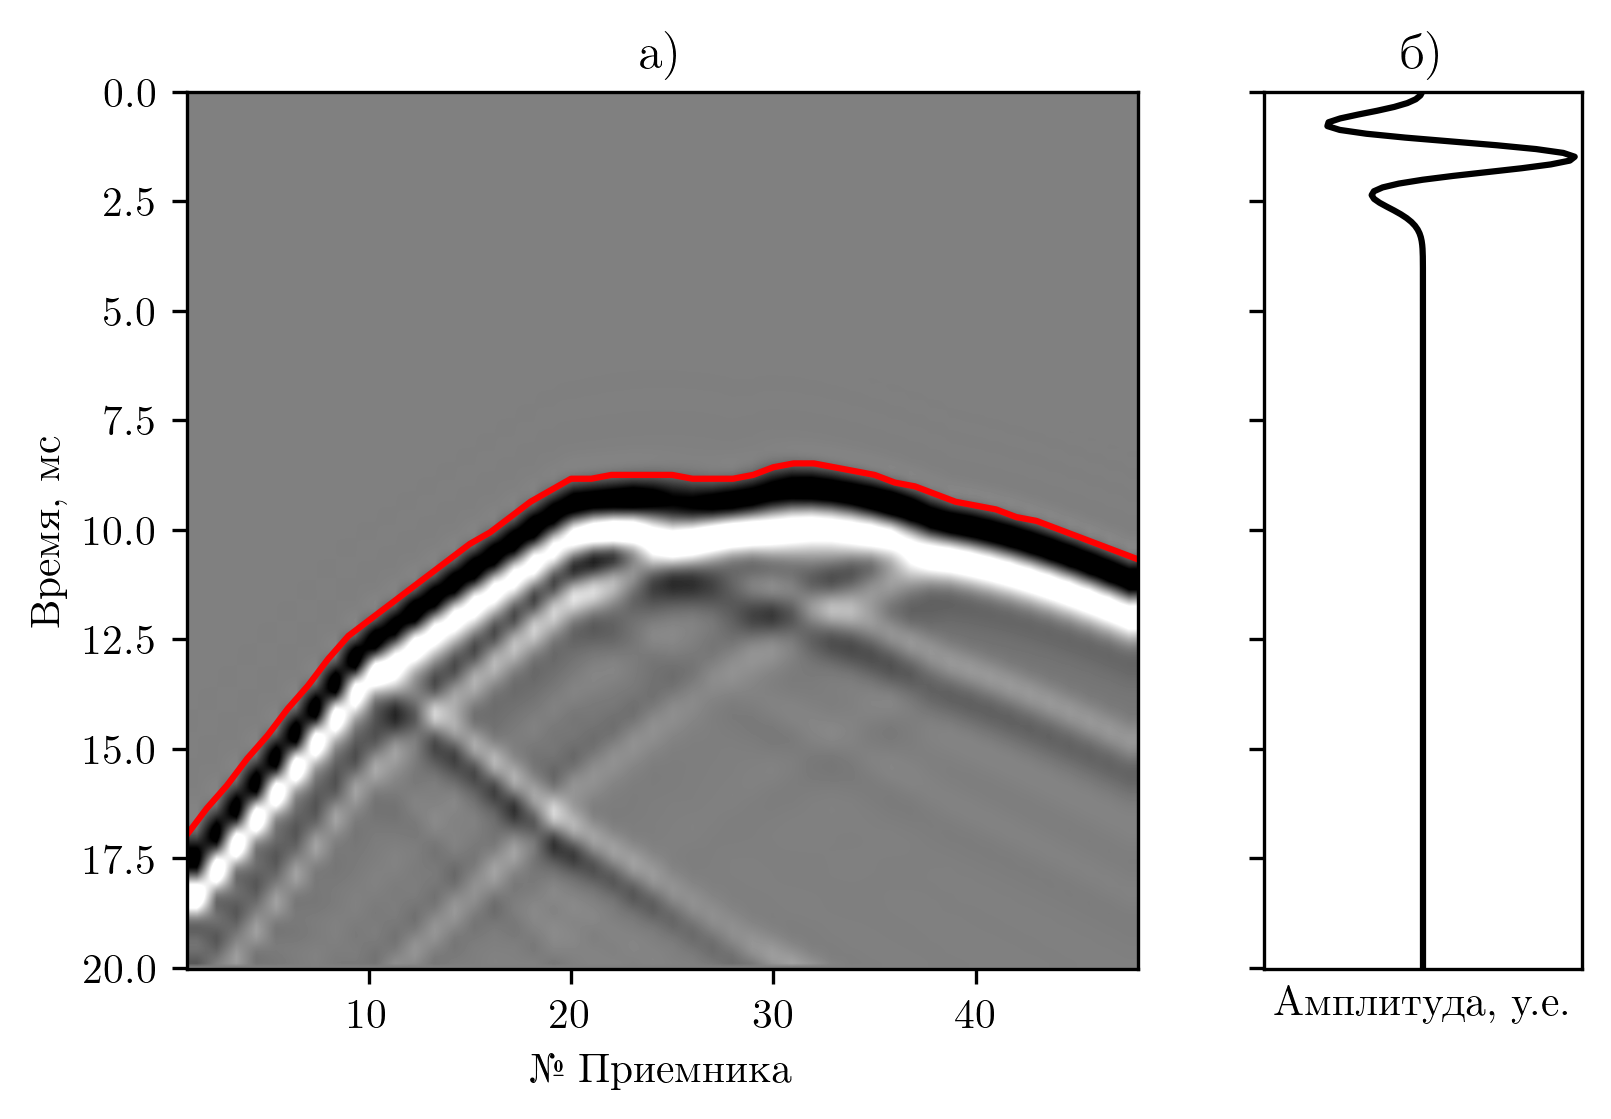

In [151]:
fig, axs = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]}, sharey=True, dpi=300, figsize=[6, 3.8])
axs[0].imshow(arr_norm, aspect='auto', cmap='gray', vmin=-2e-1, vmax=2e-1, extent=[1, 48, geometry.time_axis.time_values[-1], 0], interpolation='bilinear')
axs[0].set_ylabel('Время, мс')
axs[0].set_xlabel('№ Приемника')
axs[0].plot(np.arange(true_d.data.shape[1])+1, fbs*model.critical_dt, c='r')
axs[0].set_title('а)')

axs[1].set_title('б)')
axs[1].plot(geometry.src.data[:], geometry.time_axis.time_values, c='k')
axs[1].set_ylim(geometry.time_axis.time_values[-1], 0)
axs[1].set_xlim(-1, 1)
axs[1].set_xticks([])
axs[1].set_xticklabels([])
axs[1].set_xlabel('Амплитуда, у.е.')

plt.savefig("../../../Wavelet part pics/Pic1_minphase.png")

plt.show()

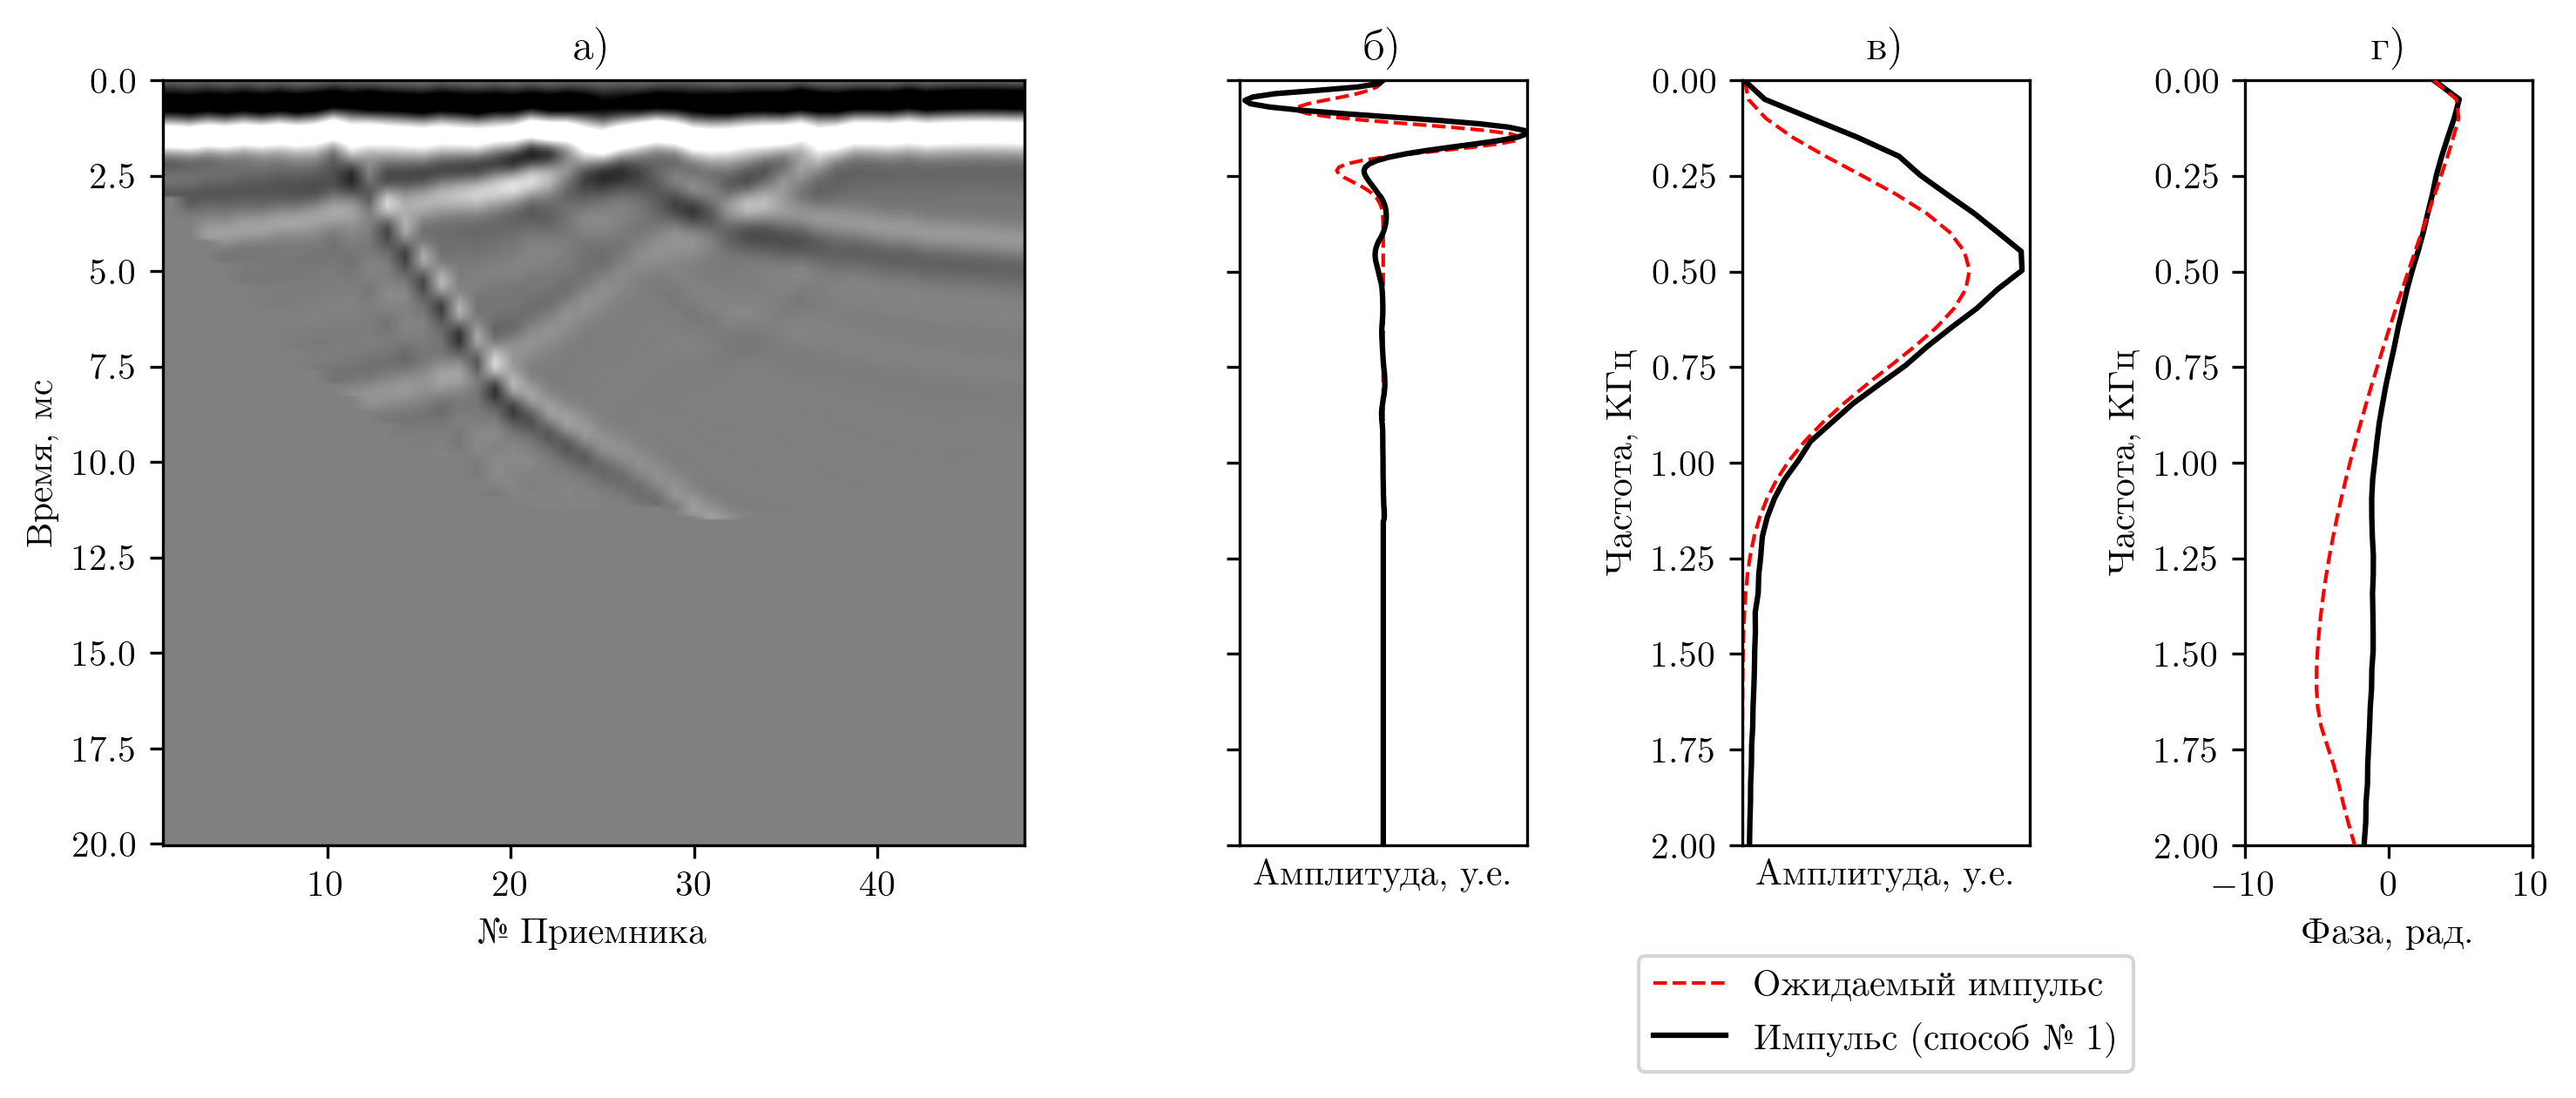

In [169]:
from scipy.fft import rfft, rfftfreq
fig, axs = plt.subplots(1, 4, gridspec_kw={'width_ratios': [3, 1, 1, 1]}, sharey=False, dpi=300, figsize=[6*0.75 + 6*0.4*3, 3.8])
plt.subplots_adjust(wspace=0.5, hspace=None)

axs[0].imshow(shifted_arr/np.linalg.norm(shifted_arr, axis=0).reshape(1, -1), aspect='auto', cmap='gray', vmin=-2e-1, vmax=2e-1, extent=[1, 48, geometry.time_axis.time_values[-1], 0], interpolation='bilinear')
fb_wavelet = np.mean(shifted_arr/np.linalg.norm(shifted_arr, axis=0).reshape(1, -1), axis=1)
fb_wavelet /= np.max(np.abs(fb_wavelet))
fb_wavelet, _ = left_taper_tukey(fb_wavelet, alpha=0.02)
axs[0].set_xlabel('№ Приемника')
axs[0].set_ylabel('Время, мс')
axs[0].set_title('а)')
axs[1].set_title('б)')

axs[1].plot(geometry.src.data[:], geometry.time_axis.time_values, c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс')
axs[1].plot(fb_wavelet, geometry.time_axis.time_values, c='k', label='Импульс (способ № 1)')

axs[1].set_ylim(geometry.time_axis.time_values[-1], 0)
axs[1].set_xlim(-1, 1)
axs[1].set_xticks([])
axs[1].set_xticklabels([])
axs[1].set_yticklabels([])
axs[1].set_ylim(20, 0)
axs[1].set_xlabel('Амплитуда, у.е.')


spec_a = np.abs(rfft(geometry.src.data[:, 0]))
spec_b = np.abs(rfft(fb_wavelet/np.max(np.abs(fb_wavelet))))

axs[2].plot(spec_a, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс')
axs[2].plot(spec_b, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='k', label='Импульс (способ № 1)')
lgd = axs[2].legend(bbox_to_anchor=(0.5, -0.32), loc='lower center')
axs[2].set_xticks([])
axs[2].set_ylim(2, 0)
# axs[2].yaxis.tick_right()
# axs[2].yaxis.set_label_position("right")
axs[2].set_ylabel('Частота, КГц')
axs[2].set_xlabel('Амплитуда, у.е.')
axs[2].set_xlim(0, 12)

axs[2].set_title('в)')

spec_a = np.unwrap(np.angle(rfft(geometry.src.data[:, 0])))
spec_b = np.unwrap(np.angle(rfft(fb_wavelet/np.max(np.abs(fb_wavelet)))))

axs[3].set_title('г)')
axs[3].plot(spec_a, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс', zorder=50)
axs[3].plot(spec_b, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='k', label='Импульс (способ № 1)', zorder=40)
axs[3].set_ylim(rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt)[-1], 0)
axs[3].set_ylim(2, 0)
# axs[3].set_xticks([-30, -20, -10, 0])
# axs[3].set_xticklabels([])
# axs[2].yaxis.tick_right()
# axs[2].yaxis.set_label_position("right")
axs[3].set_ylabel('Частота, КГц')
axs[3].set_xlabel('Фаза, рад.')
axs[3].set_xlim(-10, 10)

plt.savefig("../../../Wavelet part pics/Pic2_minphase.png", bbox_extra_artists=(lgd,), bbox_inches='tight')

plt.show()

In [160]:
geometry2 = AcquisitionGeometry(model0, rec_coordinates, src_coordinates, t0, tn, f0=f0*2.5, src_type=None, wav_data=fb_wavelet)
solver = AcousticWaveSolver(model0, geometry2, space_order=4)
# We can plot the time signature to see th
true_d2, _, _ = solver.forward(vp=model0.vp)

arr2 = np.array(true_d2.data)
arr_norm2 = arr2/np.linalg.norm(arr2, axis=0)
threshold = 0.05
fbs2 = np.argmax(np.abs(arr_norm2) > threshold, axis=0)

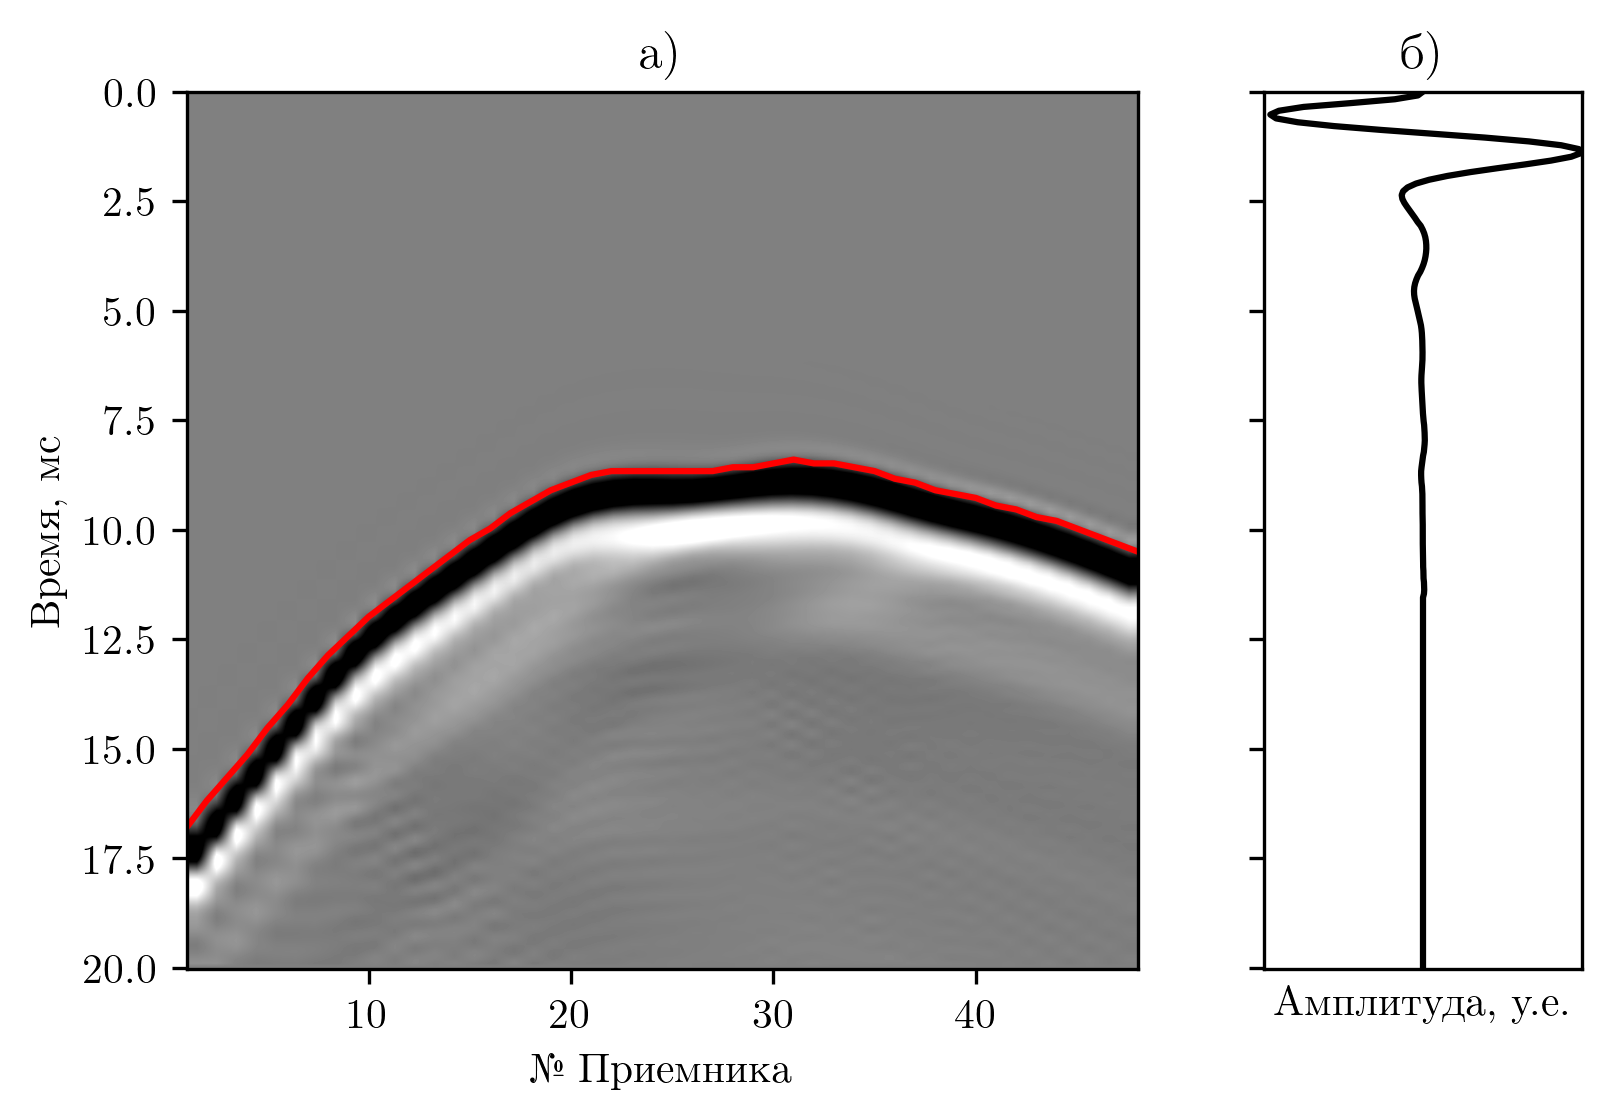

In [161]:
fig, axs = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]}, sharey=True, dpi=300, figsize=[6, 3.8])
axs[0].imshow(arr_norm2, aspect='auto', cmap='gray', vmin=-2e-1, vmax=2e-1, extent=[1, 48, geometry.time_axis.time_values[-1], 0], interpolation='bilinear')
axs[0].set_ylabel('Время, мс')
axs[0].set_xlabel('№ Приемника')
axs[0].plot(np.arange(true_d.data.shape[1])+1, fbs2*model.critical_dt, c='r')
axs[0].set_title('а)')

axs[1].set_title('б)')
axs[1].plot(geometry2.src.data[:], geometry.time_axis.time_values, c='k')
axs[1].set_ylim(geometry.time_axis.time_values[-1], 0)
axs[1].set_xlim(-1, 1)
axs[1].set_xticks([])
axs[1].set_xticklabels([])
axs[1].set_xlabel('Амплитуда, у.е.')

plt.show()

In [162]:
from examples.seismic.wavelet_inversion import wiener_deconvolution
sz = geometry.src_positions[0][1]
rec_z = geometry.rec_positions[:, 1]
wav1 = fb_wavelet/np.max(np.abs(fb_wavelet))
stf, d_obs_used, d_mod_used, rec_z_used = wiener_deconvolution(
    arr, arr2, sz, rec_z,
    time_axis=geometry.time_axis.time_values,
    first_breaks=fbs,
    eps=1e-6, normalize=False,
    kill_offset=True,
    offset_threshold=90,
    taper_before=5,
    taper_after=50,
)
wav_obs = np.convolve(wav1.squeeze(), stf)[: arr.shape[0]]
wav_obs /= np.max(np.abs(wav_obs))

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]


In [163]:
geometry3 = AcquisitionGeometry(model0, rec_coordinates, src_coordinates, t0, tn, f0=f0*2.5, src_type=None, wav_data=wav_obs)
solver = AcousticWaveSolver(model0, geometry3, space_order=4)
# We can plot the time signature to see th
true_d3, _, _ = solver.forward(vp=model0.vp)

arr3 = np.array(true_d3.data)
arr_norm3 = arr3/np.linalg.norm(arr2, axis=0)
threshold = 0.04
fbs3 = np.argmax(np.abs(arr_norm3) > threshold, axis=0)

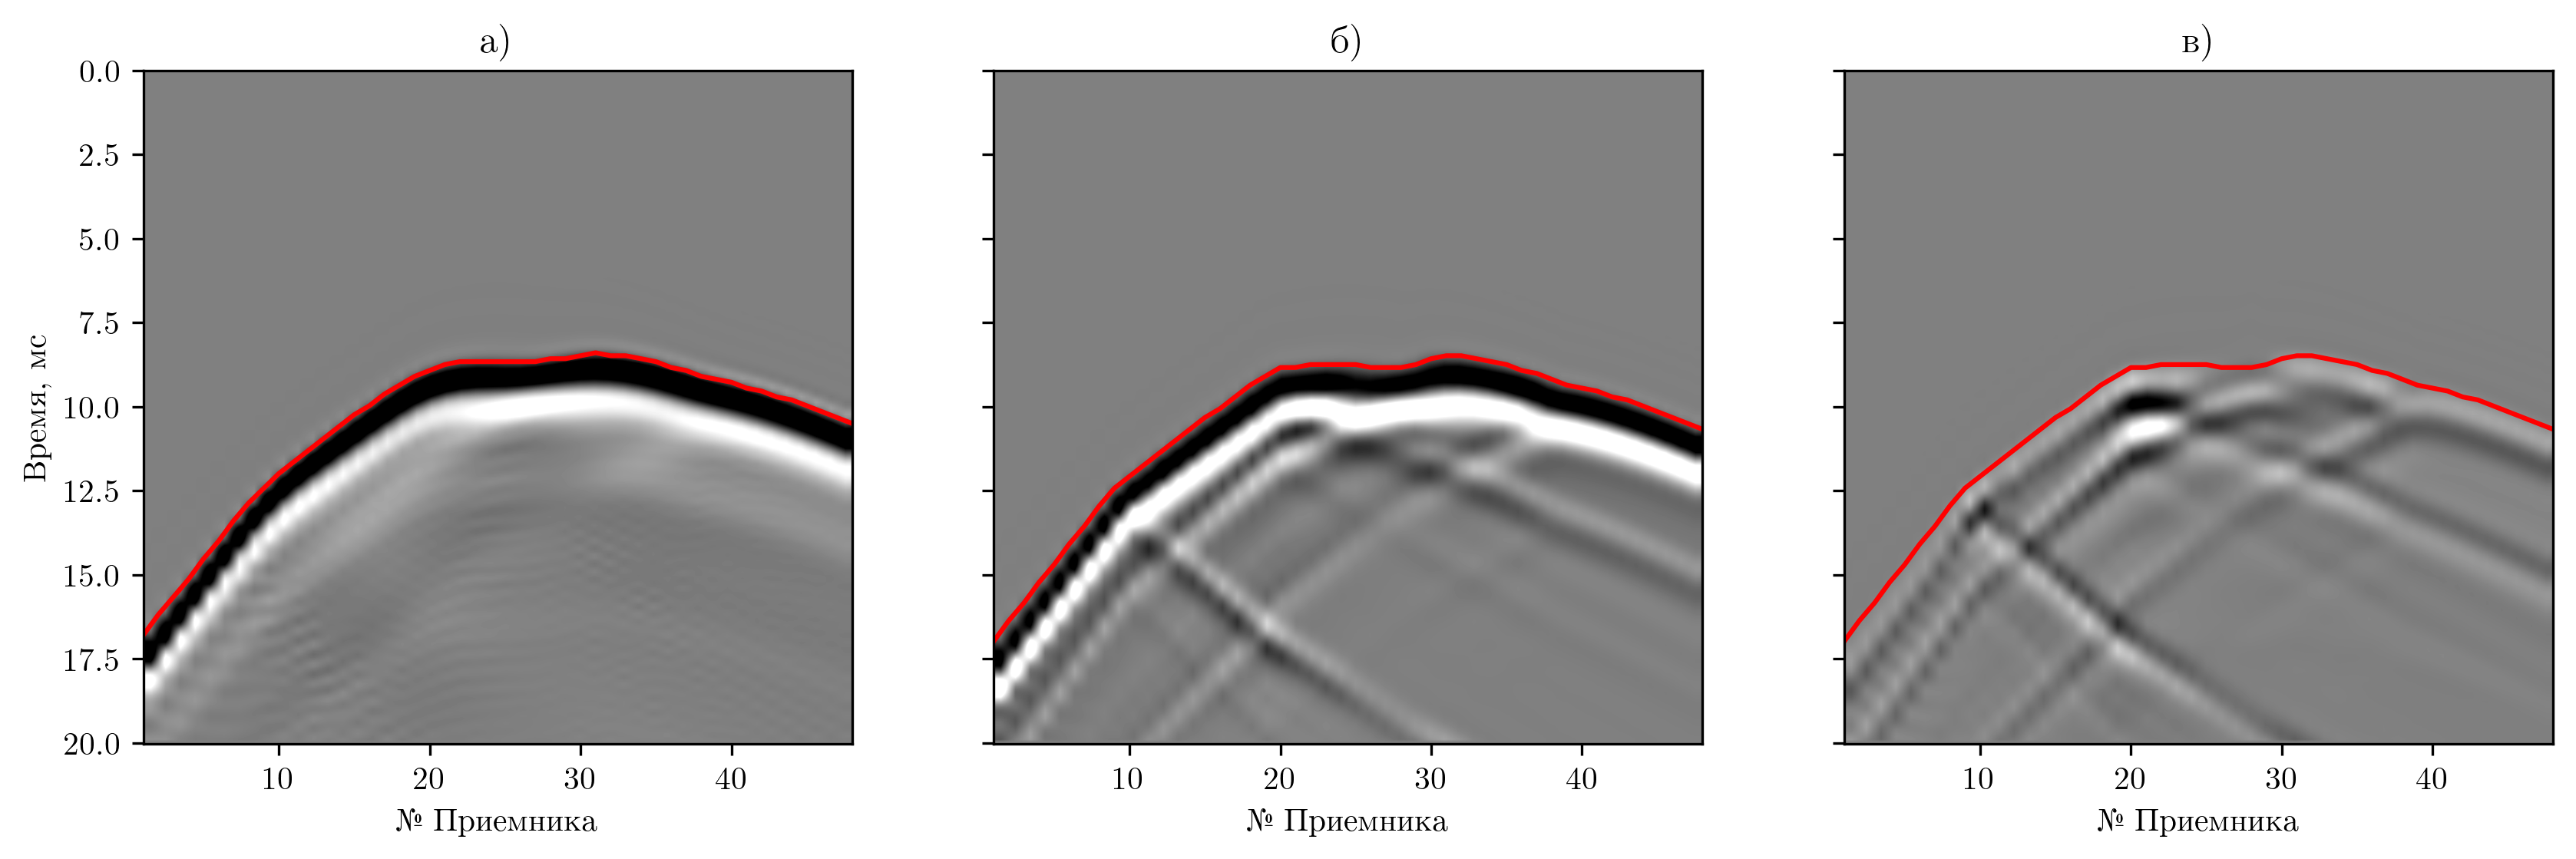

In [164]:
from scipy.fft import rfft, rfftfreq
fig, axs = plt.subplots(1, 3, gridspec_kw={'width_ratios': [3, 3, 3]}, dpi=300, figsize=[6*0.75*3, 3.8])
axs[0].imshow(arr_norm2, aspect='auto', cmap='gray', vmin=-2e-1, vmax=2e-1, extent=[1, 48, geometry.time_axis.time_values[-1], 0], interpolation='bilinear')
axs[0].set_ylabel('Время, мс')
axs[0].set_xlabel('№ Приемника')
axs[0].plot(np.arange(true_d.data.shape[1])+1, fbs2*model.critical_dt, c='r')
axs[0].set_title('а)')

axs[1].imshow(arr_norm, aspect='auto', cmap='gray', vmin=-2e-1, vmax=2e-1, extent=[1, 48, geometry.time_axis.time_values[-1], 0], interpolation='bilinear')
# axs[1].set_ylabel('Время, мс')
axs[1].set_xlabel('№ Приемника')
axs[1].plot(np.arange(true_d.data.shape[1])+1, fbs*model.critical_dt, c='r')
axs[1].set_title('б)')
axs[1].set_yticklabels([])


axs[2].imshow(arr_norm3-arr_norm, aspect='auto', cmap='gray', vmin=-2e-1, vmax=2e-1, extent=[1, 48, geometry.time_axis.time_values[-1], 0], interpolation='bilinear')
# axs[1].set_ylabel('Время, мс')
axs[2].set_xlabel('№ Приемника')
axs[2].plot(np.arange(true_d.data.shape[1])+1, fbs*model.critical_dt, c='r')
axs[2].set_title('в)')
axs[2].set_yticklabels([])

plt.savefig("../../../Wavelet part pics/Pic3_minphase.png")

plt.show()


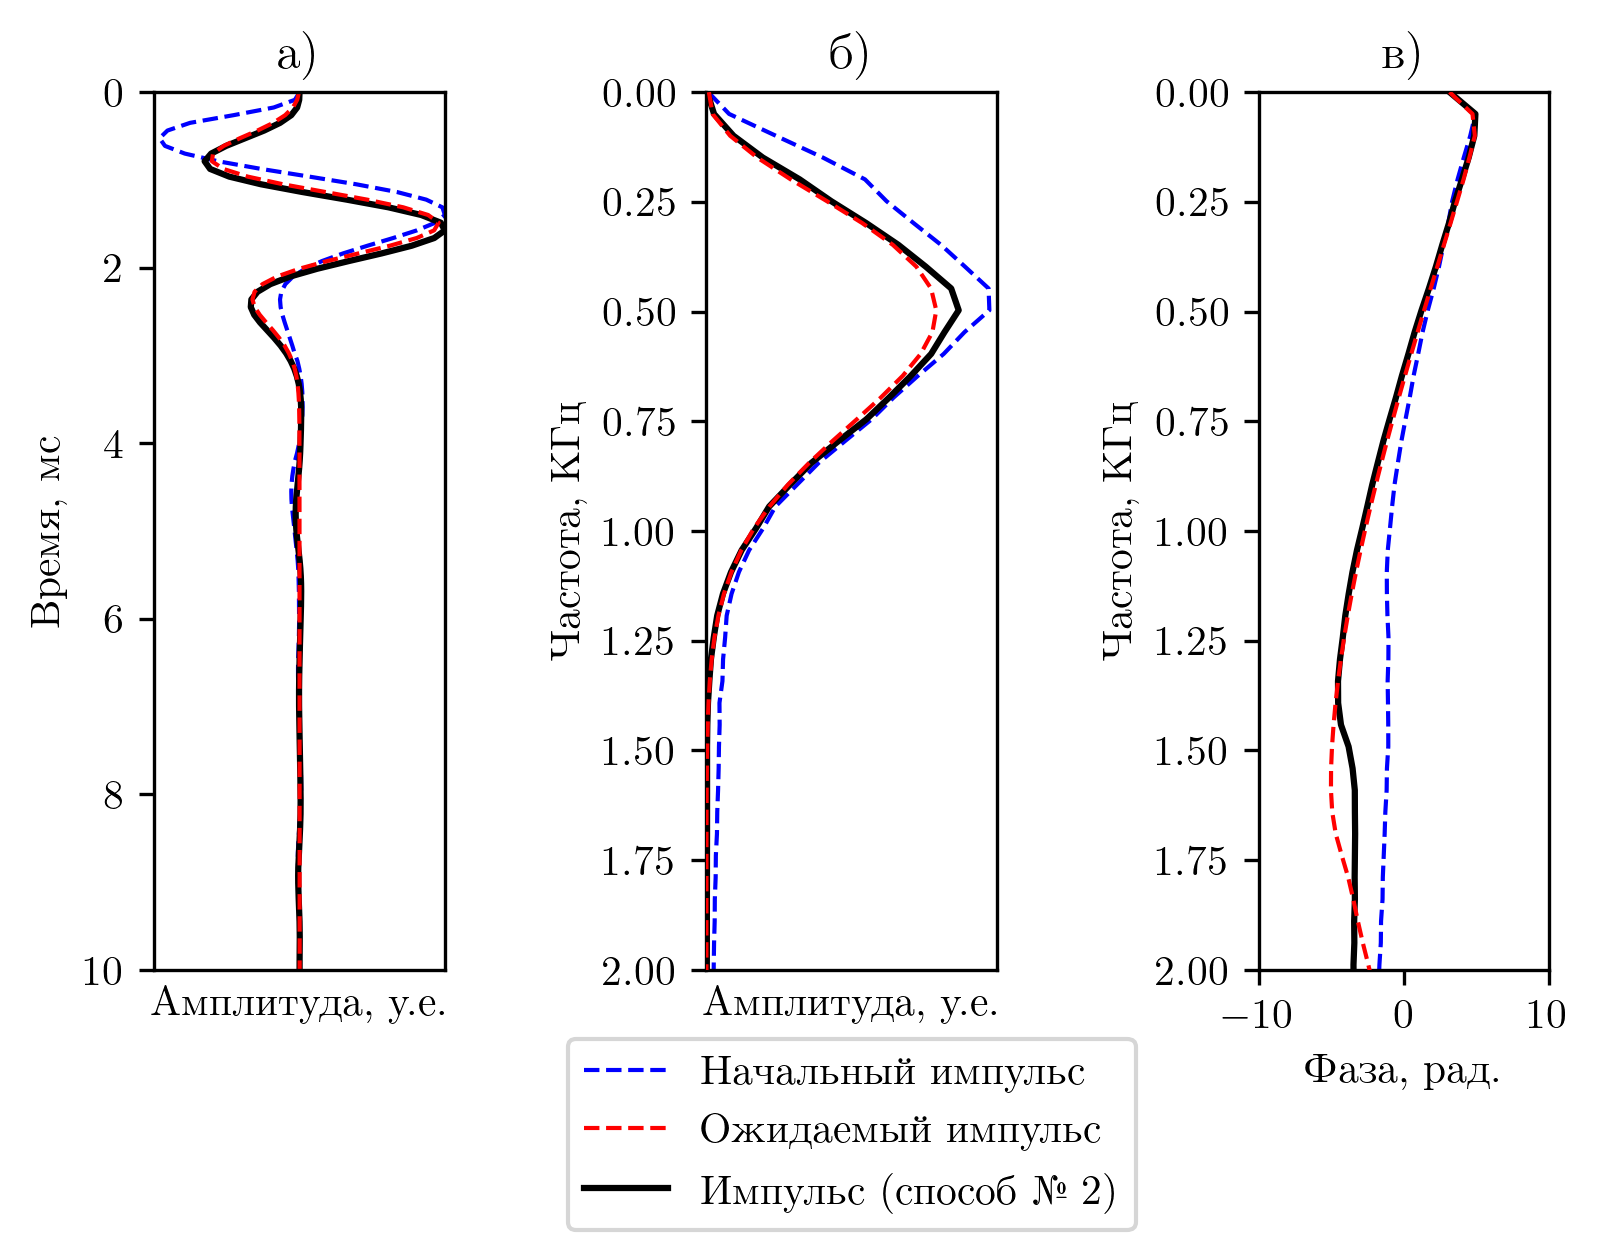

In [168]:
from scipy.fft import rfft, rfftfreq
fig, axs = plt.subplots(1, 3, gridspec_kw={'width_ratios': [1, 1, 1]}, dpi=300, figsize=[6, 3.8])
plt.subplots_adjust(wspace=0.9, hspace=None)
axs[0].set_title('а)')
axs[0].plot(fb_wavelet, geometry.time_axis.time_values, c='b', linestyle='--', linewidth=1, label='Начальный импульс')
axs[0].plot(wav_obs, geometry.time_axis.time_values, c='k', label='Импульс (способ № 2)')
axs[0].plot(geometry.src.data[:], geometry.time_axis.time_values, c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс')
axs[0].set_ylim(geometry.time_axis.time_values[-1], 0)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(10, 0)
axs[0].set_xticks([])
axs[0].set_xticklabels([])
# axs[0].set_yticklabels([])
axs[0].set_ylabel('Время, мс')
axs[0].set_xlabel('Амплитуда, у.е.')

axs[1].set_title('б)')

spec_a = np.abs(rfft(fb_wavelet))
spec_b = np.abs(rfft(geometry.src.data[:, 0]))
spec_c = np.abs(rfft(wav_obs))

axs[1].plot(spec_a, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='b', linestyle='--', linewidth=1, label='Начальный импульс')
axs[1].plot(spec_b, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс', zorder=50)
axs[1].plot(spec_c, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='k', label='Импульс (способ № 2)', zorder=40)
axs[1].set_ylim(rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt)[-1], 0)
axs[1].set_ylim(2, 0)
axs[1].set_xlim(0, 12)
axs[1].set_xticks([])
axs[1].set_xticklabels([])
lgd = axs[1].legend(bbox_to_anchor=(0.5, -0.32), loc='lower center')
# axs[1].yaxis.tick_right()
# axs[1].yaxis.set_label_position("right")
# axs[1].set_ylabel('Частота, КГц', rotation=-90, labelpad=12)
axs[1].set_ylabel('Частота, КГц')
axs[1].set_xlabel('Амплитуда, у.е.')


axs[2].set_title('в)')
spec_a = np.unwrap(np.angle(rfft(fb_wavelet)))
spec_b = np.unwrap(np.angle(rfft(geometry.src.data[:, 0])))
spec_c = np.unwrap(np.angle(rfft(wav_obs)))
axs[2].plot(spec_a, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='b', linestyle='--', linewidth=1, label='Начальный импульс')
axs[2].plot(spec_b, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс', zorder=50)
axs[2].plot(spec_c, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='k', label='Импульс (способ № 2)', zorder=40)
axs[2].set_ylim(rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt)[-1], 0)
axs[2].set_ylim(2, 0)
# axs[2].set_xticks([-30, -20, -10, 0])
# axs[2].set_xticklabels([/])
# axs[2].yaxis.tick_right()
# axs[2].yaxis.set_label_position("right")
axs[2].set_ylabel('Частота, КГц')
axs[2].set_xlabel('Фаза, рад.')
axs[2].set_xlim(-10, 10)

# plt.tight_layout()
plt.savefig("../../../Wavelet part pics/Pic4_minphase.png", bbox_extra_artists=(lgd,), bbox_inches='tight')

plt.show()


In [170]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator


In [171]:
from examples.seismic import Receiver
def set_wavelet_in_geometry(geometry, wavelet_1d):
    """
    geometry.src.data expects (nt, nsrc). We pass the same time series for each source (nsrc==1 here).
    wavelet_1d: shape (nt,)
    """
    w = np.asarray(wavelet_1d).reshape(-1, 1)
    geometry._src_type = None          # let us override with raw samples
    geometry.wav_data = w.reshape(-1)  # keep for our own bookkeeping
    geometry.src.data[:] = w

def forward_data(model, geometry, solver):
    """
    Return synthetic receiver data y = G f for the current geometry.src.data.
    """
    d_syn = Receiver(name='d_syn',
                     grid=model.grid,
                     time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, src=geometry.src, rec=d_syn, save=False)
    return np.array(d_syn.data)

def adjoint_to_source(model, geometry, solver, rec_traces):
    """
    Apply G^T to 'rec_traces' (shape (nt, nrec)), i.e. inject at receivers, backprop, sample at source.
    Returns a 1D array of length nt (B^T L^{-T} S^T rec_traces).
    """
    d = Receiver(name='d', grid=model.grid, time_range=geometry.time_axis,
                 coordinates=geometry.rec_positions)
    d.data[:] = rec_traces
    srca, _, _ = solver.adjoint(vp=model.vp, rec=d)  # srca shape: (nt, nsrc) -> we use a single source
    return np.array(srca.data).reshape(-1)

# --- Right-hand side b = G^T W^T W d
def precompute_b(model, geometry, solver, d_obs):
    """
    d_obs: observed data shaped (nrec, nt) or (nt, nrec). We'll accept your dataset shape.
    """
    # Devito expects (nt, nrec)
    if d_obs.shape[0] != geometry.time_axis.num:
        d_obs_tn = d_obs.T
    else:
        d_obs_tn = d_obs
    b = adjoint_to_source(model, geometry, solver, d_obs_tn)     # G^T W d  (W is self-adjoint)
    return b

# --- Linear operator apply: A v = G^T W G v + lam * v
def apply_A(model, geometry, solver, v, lam=0.0):
    set_wavelet_in_geometry(geometry, v)
    y = forward_data(model, geometry, solver)                 # y = G v  (nt, nrec)
    srca = adjoint_to_source(model, geometry, solver, y)    # G^T W y
    # srca, window = left_taper_tukey(srca.reshape(-1), alpha=0.01)
    return srca.reshape(-1) + lam * v

In [204]:
max_iter = 10
lam = 5e-5
t0 = 0

In [205]:
geometry_real = AcquisitionGeometry(
    model0, rec_coordinates, src_coordinates,
    t0, tn, f0=f0, src_type='Ricker'
)

geometry_real = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type=None, wav_data=-wav_min)


    iter 01: alpha=7.390e+01, rel||g||=1.044e+00, approx J=-8.711e-03
    iter 02: alpha=7.390e+01, rel||g||=3.625e+00, approx J=1.155e-03
    iter 03: alpha=1.835e+01, rel||g||=7.833e-01, approx J=-1.060e-02
    iter 04: alpha=1.538e+01, rel||g||=2.652e-01, approx J=-1.123e-02
    iter 05: alpha=1.742e+01, rel||g||=2.464e-01, approx J=-1.138e-02
    iter 06: alpha=2.348e+02, rel||g||=1.635e-01, approx J=-1.235e-02
    iter 07: alpha=2.715e+02, rel||g||=8.279e-01, approx J=-1.091e-02
    iter 08: alpha=5.125e+01, rel||g||=4.868e-01, approx J=-1.224e-02
    iter 09: alpha=3.735e+01, rel||g||=6.276e-01, approx J=-1.217e-02
    iter 10: alpha=1.756e+01, rel||g||=9.738e-02, approx J=-1.253e-02


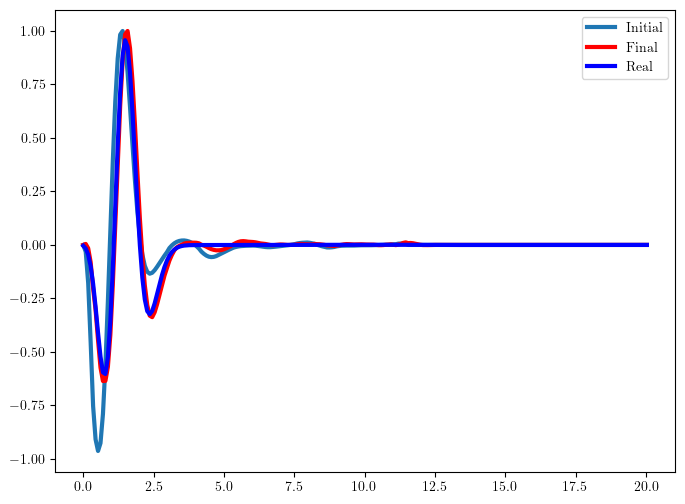

In [208]:
current_wavelet = np.copy(fb_wavelet)
initial_wavelet = np.copy(fb_wavelet)

d_obs = np.copy(arr)
geometry = AcquisitionGeometry(
    model0, rec_coordinates, src_coordinates,
    t0, tn, f0=f0 * 2, src_type=None, wav_data=current_wavelet
)
solver = AcousticWaveSolver(model0, geometry, space_order=4)
prev_wavelet = current_wavelet.copy()

b = precompute_b(model0, geometry, solver, d_obs)

# Initial gradient g0 = A f0 - b
Af = apply_A(model0, geometry, solver, current_wavelet, lam=lam)
g = Af - b
g_prev = None

for i in range(max_iter):
    # Exact steepest-descent line search for i==0, else Barzilai–Borwein
    if i == 0:
        # q = A g
        Ag = apply_A(model0, geometry, solver, g, lam=lam)
        denom = np.dot(g, Ag) + 1e-18
        alpha = np.dot(g, g) / denom
        # alpha *=
    else:
        s = current_wavelet - prev_wavelet
        y = g - g_prev
        sy = np.dot(s, y)
        yy = np.dot(y, y) + 1e-18
        if abs(sy) > 1e-18:
            alpha = np.dot(s, s) / sy
        else:
            alpha = 1e-3

#     # Update
    prev_wavelet = current_wavelet
    g_prev = g
    current_wavelet = current_wavelet - alpha * g

    # Recompute gradient at new iterate
    Af = apply_A(model0, geometry, solver, current_wavelet, lam=lam)
    g = Af - b

    rel_grad = np.linalg.norm(g) / (np.linalg.norm(b) + 1e-18)
    misfit = 0.5 * np.dot(current_wavelet, Af) - np.dot(current_wavelet, b)  # J up to const (quadratic form)
    print(f"    iter {i+1:02d}: alpha={alpha:.3e}, rel||g||={rel_grad:.3e}, approx J={misfit:.3e}")
    # plt.plot(geometry.time_axis.time_values, current_wavelet, label=f"{i}")
    # Simple stopping
    # if rel_grad < 1e-4:
    #     print("    Converged on wavelet update.")
    #     break
# plt.plot(geometry.time_axis.time_values, initial_wavelet/20, label=f"Initial", c='k', linewidth=3, zorder=100)

fin_wavelet, _ = left_taper_tukey(current_wavelet, alpha=0.02)
# fin_wavelet = current_wavelet

fin_wavelet /= np.max(np.abs(fin_wavelet))
plt.plot(geometry.time_axis.time_values, initial_wavelet, label=f"Initial", linewidth=3, zorder=100)
plt.plot(geometry.time_axis.time_values, fin_wavelet, label=f"Final", c='r', linewidth=3, zorder=100)
plt.plot(geometry.time_axis.time_values, geometry_real.src.data, label=f"Real", c='b', linewidth=3, zorder=100)
plt.legend(loc='upper right')

plt.show()

In [209]:
geometry = AcquisitionGeometry(
    model0, rec_coordinates, src_coordinates,
    t0, tn, f0=f0, src_type='Ricker'
)
geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=f0, src_type=None, wav_data=-wav_min)


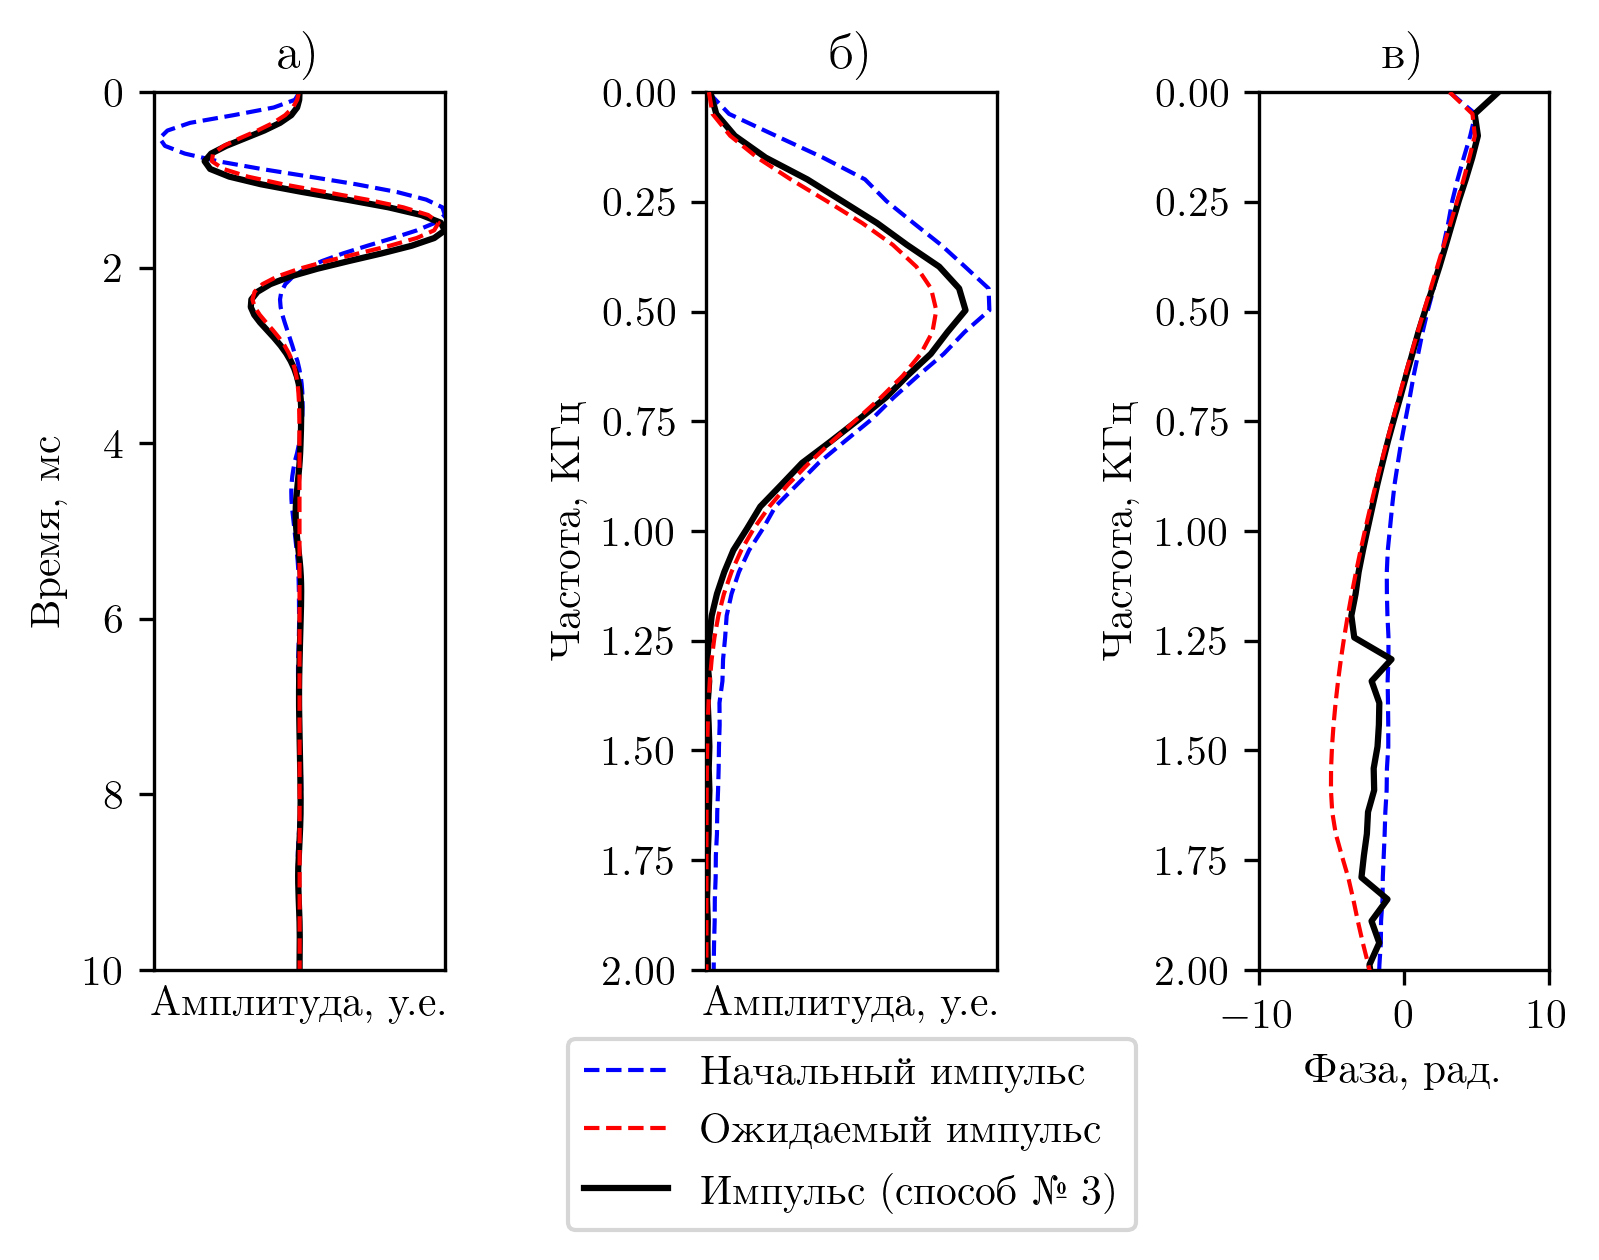

In [222]:
from scipy.fft import rfft, rfftfreq
fig, axs = plt.subplots(1, 3, gridspec_kw={'width_ratios': [1, 1, 1]}, dpi=300, figsize=[6, 3.8])
plt.subplots_adjust(wspace=0.9, hspace=None)
axs[0].set_title('а)')
axs[0].plot(fb_wavelet, geometry.time_axis.time_values, c='b', linestyle='--', linewidth=1, label='Начальный импульс')
axs[0].plot(wav_obs, geometry.time_axis.time_values, c='k', label='Импульс (способ № 2)')
axs[0].plot(geometry.src.data[:], geometry.time_axis.time_values, c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс')
axs[0].set_ylim(geometry.time_axis.time_values[-1], 0)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(10, 0)
axs[0].set_xticks([])
axs[0].set_xticklabels([])
# axs[0].set_yticklabels([])
axs[0].set_ylabel('Время, мс')
axs[0].set_xlabel('Амплитуда, у.е.')

axs[1].set_title('б)')

spec_a = np.abs(rfft(fb_wavelet))
spec_b = np.abs(rfft(geometry.src.data[:, 0]))
spec_c = np.abs(rfft(fin_wavelet))

axs[1].plot(spec_a, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='b', linestyle='--', linewidth=1, label='Начальный импульс')
axs[1].plot(spec_b, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс', zorder=50)
axs[1].plot(spec_c, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='k', label='Импульс (способ № 3)', zorder=40)
axs[1].set_ylim(rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt)[-1], 0)
axs[1].set_ylim(2, 0)
axs[1].set_xticks([])
axs[1].set_xticklabels([])
lgd = axs[1].legend(bbox_to_anchor=(0.5, -0.32), loc='lower center')
# axs[1].yaxis.tick_right()
# axs[1].yaxis.set_label_position("right")
# axs[1].set_ylabel('Частота, КГц', rotation=-90, labelpad=12)
axs[1].set_ylabel('Частота, КГц')
axs[1].set_xlabel('Амплитуда, у.е.')
axs[1].set_xlim(0, 12)


axs[2].set_title('в)')
spec_a = np.unwrap(np.angle(rfft(fb_wavelet)))
spec_b = np.unwrap(np.angle(rfft(geometry.src.data[:, 0])))
spec_c = np.unwrap(np.angle(rfft(fin_wavelet)))+6.5
axs[2].plot(spec_a, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='b', linestyle='--', linewidth=1, label='Начальный импульс')
axs[2].plot(spec_b, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='r', linestyle='--', linewidth=1, label='Ожидаемый импульс', zorder=50)
axs[2].plot(spec_c, rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt), c='k', label='Импульс (способ № 3)', zorder=40)
axs[2].set_ylim(rfftfreq(geometry.time_axis.time_values.size, d=model.critical_dt)[-1], 0)
axs[2].set_ylim(2, 0)
axs[2].set_xlim(-25, 0)

# axs[2].set_xticks([-30, -20, -10, 0])
# axs[2].set_xticklabels([])
# axs[2].yaxis.tick_right()
# axs[2].yaxis.set_label_position("right")
axs[2].set_ylabel('Частота, КГц')
axs[2].set_xlabel('Фаза, рад.')
axs[2].set_xlim(-10, 10)
plt.savefig("../../../Wavelet part pics/Pic5_minphase.png", bbox_extra_artists=(lgd,), bbox_inches='tight')

# plt.tight_layout()
plt.show()


# Full-Waveform Inversion


## Formulation

Full-waveform inversion (FWI) aims to invert an accurate model of the discrete wave velocity, $\mathbf{c}$, or equivalently the square slowness of the wave, $\mathbf{m} = \frac{1}{\mathbf{c}^2}$, from a given set of measurements of the pressure wavefield $\mathbf{u}$. This can be expressed as the following optimization problem [1, 2]:

\begin{aligned}
	\mathop{\hbox{minimize}}_{\mathbf{m}} \Phi_s(\mathbf{m})&=\frac{1}{2}\left\lVert\mathbf{P}_r
	\mathbf{u} - \mathbf{d}\right\rVert_2^2 \\
	\mathbf{u} &= \mathbf{A}(\mathbf{m})^{-1} \mathbf{P}_s^T \mathbf{q}_s, 
\end{aligned}

where $\mathbf{P}_r$ is the sampling operator at the receiver locations, $\mathbf{P}_s^T$ is the injection operator at the source locations, $\mathbf{A}(\mathbf{m})$ is the operator representing the discretized wave equation matrix, $\mathbf{u}$ is the discrete synthetic pressure wavefield, $\mathbf{q}_s$ is the corresponding pressure source and $\mathbf{d}$ is the measured data. It is worth noting that $\mathbf{m}$ is the unknown in this formulation and that multiple implementations of the wave equation operator $\mathbf{A}(\mathbf{m})$ are possible. 

We have already defined a concrete solver scheme for $\mathbf{A}(\mathbf{m})$ in the first tutorial, including appropriate implementations of the sampling operator $\mathbf{P}_r$ and source term $\mathbf{q}_s$.

To solve this optimization problem using a gradient-based method, we use the
adjoint-state method to evaluate the gradient $\nabla\Phi_s(\mathbf{m})$:

\begin{align}
 \nabla\Phi_s(\mathbf{m})=\sum_{\mathbf{t} =1}^{n_t}\mathbf{u}[\mathbf{t}] \mathbf{v}_{tt}[\mathbf{t}] =\mathbf{J}^T\delta\mathbf{d}_s,
\end{align}

where $n_t$ is the number of computational time steps, $\delta\mathbf{d}_s = \left(\mathbf{P}_r \mathbf{u} - \mathbf{d} \right)$ is the data residual (difference between the measured data and the modelled data), $\mathbf{J}$ is the Jacobian operator and $\mathbf{v}_{tt}$ is the second-order time derivative of the adjoint wavefield solving:

\begin{align}
 \mathbf{A}^T(\mathbf{m}) \mathbf{v} = \mathbf{P}_r^T \delta\mathbf{d}.
\end{align}

We see that the gradient of the FWI function is the previously defined imaging condition with an extra second-order time derivative. We will therefore reuse the operators defined previously inside a Devito wrapper.

## FWI gradient operator

To compute a single gradient $\nabla\Phi_s(\mathbf{m})$ in our optimization workflow we again use `solver.forward` to compute the entire forward wavefield $\mathbf{u}$ and a similar pre-defined gradient operator to compute the adjoint wavefield `v`. The gradient operator provided by our `solver` utility also computes the correlation between the wavefields, allowing us to encode a similar procedure to the previous imaging tutorial as our gradient calculation:

- Simulate the forward wavefield with the background velocity model to get the synthetic data and save the full wavefield $\mathbf{u}$
- Compute the data residual
- Back-propagate the data residual and compute on the fly the gradient contribution at each time step. 

This procedure is applied to multiple source positions and summed to obtain a gradient image of the subsurface. We again prepare the source locations for each shot and visualize them, before defining a single gradient computation over a number of shots as a single function.

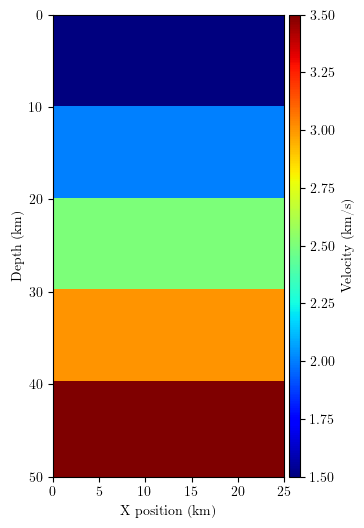

In [30]:
#NBVAL_IGNORE_OUTPUT

# Prepare the varying source locations sources
source_locations = np.empty((nshots, 2), dtype=np.float32)
source_locations[:, 0] = 30.
source_locations[:, 1] = np.linspace(0., 1000, num=nshots)

plot_velocity(model, source=source_locations)

In [31]:
from devito import Eq, Operator

# Computes the residual between observed and synthetic data into the residual
def compute_residual(residual, dobs, dsyn):
    if residual.grid.distributor.is_parallel:
        # If we run with MPI, we have to compute the residual via an operator
        # First make sure we can take the difference and that receivers are at the 
        # same position
        assert np.allclose(dobs.coordinates.data[:], dsyn.coordinates.data)
        assert np.allclose(residual.coordinates.data[:], dsyn.coordinates.data)
        # Create a difference operator
        diff_eq = Eq(residual, dsyn.subs({dsyn.dimensions[-1]: residual.dimensions[-1]}) -
                               dobs.subs({dobs.dimensions[-1]: residual.dimensions[-1]}))
        Operator(diff_eq)()
    else:
        # A simple data difference is enough in serial
        residual.data[:] = dsyn.data[:] - dobs.data[:]
    
    return residual

In [32]:
# Create FWI gradient kernel 
from devito import Function, TimeFunction, norm
from examples.seismic import Receiver

import scipy
def fwi_gradient(vp_in):    
    # Create symbols to hold the gradient
    grad = Function(name="grad", grid=model.grid)
    # Create placeholders for the data residual and data
    residual = Receiver(name='residual', grid=model.grid,
                        time_range=geometry.time_axis, 
                        coordinates=geometry.rec_positions)
    d_obs = Receiver(name='d_obs', grid=model.grid,
                     time_range=geometry.time_axis, 
                     coordinates=geometry.rec_positions)
    d_syn = Receiver(name='d_syn', grid=model.grid,
                     time_range=geometry.time_axis, 
                     coordinates=geometry.rec_positions)
    objective = 0.
    for i in range(nshots):
        # Update source location
        geometry.src_positions[0, :] = source_locations[i, :]
        
        # Generate synthetic data from true model
        _, _, _ = solver.forward(vp=model.vp, rec=d_obs)
        
        # Compute smooth data and full forward wavefield u0
        _, u0, _ = solver.forward(vp=vp_in, save=True, rec=d_syn)
        
        # Compute gradient from data residual and update objective function 
        compute_residual(residual, d_obs, d_syn)
        
        objective += .5*norm(residual)**2
        solver.gradient(rec=residual, u=u0, vp=vp_in, grad=grad)
    
    return objective, grad

Having defined our FWI gradient procedure we can compute the initial iteration from our starting model. This allows us to visualize the gradient alongside the model perturbation and the effect of the gradient update on the model.

In [33]:
# Compute gradient of initial model
ff, update = fwi_gradient(model0.vp)
assert np.isclose(ff, 57283, rtol=1e0)

AttributeError: 'TimeDimension' object has no attribute 'uses_symbolic_factor'

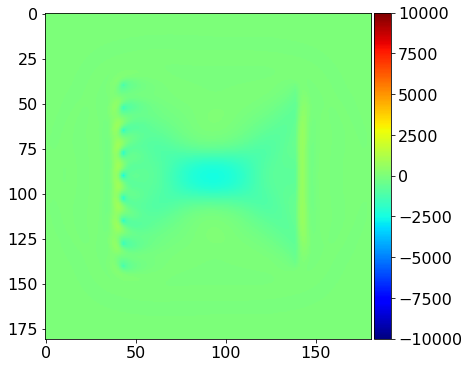

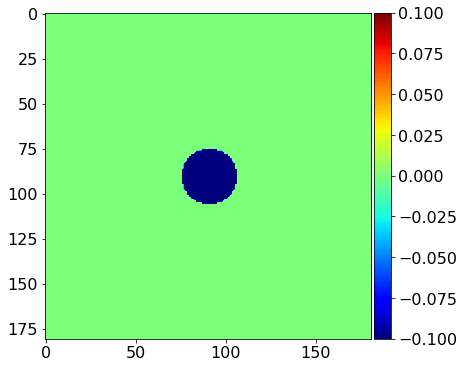

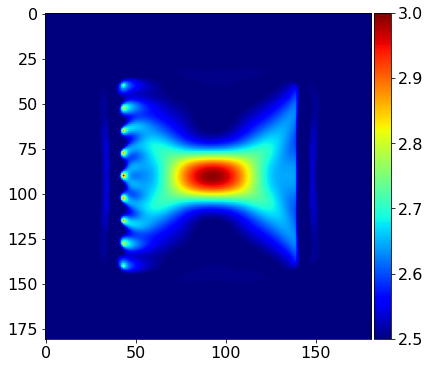

In [ ]:
#NBVAL_IGNORE_OUTPUT
from devito import mmax
from examples.seismic import plot_image

# Plot the FWI gradient
plot_image(-update.data, vmin=-1e4, vmax=1e4, cmap="jet")

# Plot the difference between the true and initial model.
# This is not known in practice as only the initial model is provided.
plot_image(model0.vp.data - model.vp.data, vmin=-1e-1, vmax=1e-1, cmap="jet")

# Show what the update does to the model
alpha = .5 / mmax(update)
plot_image(model0.vp.data + alpha*update.data, vmin=2.5, vmax=3.0, cmap="jet")

We see that the gradient and the true perturbation have the same sign, therefore, with an appropriate scaling factor, we will update the model in the correct direction.

In [ ]:
from devito import Min, Max
# Define bounding box constraints on the solution.
def update_with_box(vp, alpha, dm, vmin=2.0, vmax=3.5):
    """
    Apply gradient update in-place to vp with box constraint

    Notes:
    ------
    For more advanced algorithm, one will need to gather the non-distributed
    velocity array to apply constrains and such.
    """
    update = vp + alpha * dm
    update_eq = Eq(vp, Max(Min(update, vmax), vmin))
    Operator(update_eq)()

In [ ]:
#NBVAL_SKIP

from devito import mmax

# Run FWI with gradient descent
history = np.zeros((fwi_iterations, 1))
for i in range(0, fwi_iterations):
    # Compute the functional value and gradient for the current
    # model estimate
    phi, direction = fwi_gradient(model0.vp)
    
    # Store the history of the functional values
    history[i] = phi
    
    # Artificial Step length for gradient descent
    # In practice this would be replaced by a Linesearch (Wolfe, ...)
    # that would guarantee functional decrease Phi(m-alpha g) <= epsilon Phi(m)
    # where epsilon is a minimum decrease constant
    alpha = .05 / mmax(direction)
    
    # Update the model estimate and enforce minimum/maximum values
    update_with_box(model0.vp , alpha , direction)
    
    # Log the progress made
    print('Objective value is %f at iteration %d' % (phi, i+1))

Objective value is 39292.605833 at iteration 1
Objective value is 24506.628229 at iteration 2
Objective value is 14386.573665 at iteration 3
Objective value is 7907.616850 at iteration 4
Objective value is 3960.106497 at iteration 5


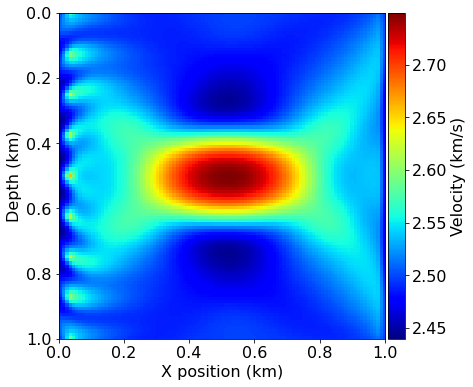

In [ ]:
#NBVAL_IGNORE_OUTPUT

# Plot inverted velocity model
plot_velocity(model0)

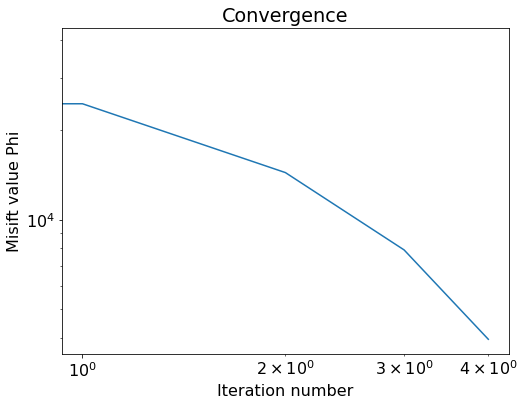

In [ ]:
#NBVAL_SKIP
import matplotlib.pyplot as plt

# Plot objective function decrease
plt.figure()
plt.loglog(history)
plt.xlabel('Iteration number')
plt.ylabel('Misift value Phi')
plt.title('Convergence')
plt.show()

## References

[1] _Virieux, J. and Operto, S.: An overview of full-waveform inversion in exploration geophysics, GEOPHYSICS, 74, WCC1–WCC26, doi:10.1190/1.3238367, http://library.seg.org/doi/abs/10.1190/1.3238367, 2009._

[2] _Haber, E., Chung, M., and Herrmann, F. J.: An effective method for parameter estimation with PDE constraints with multiple right hand sides, SIAM Journal on Optimization, 22, http://dx.doi.org/10.1137/11081126X, 2012._

<sup>This notebook is part of the tutorial "Optimised Symbolic Finite Difference Computation with Devito" presented at the Intel® HPC Developer Conference 2017.</sup>